In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [232]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [233]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [234]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [235]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [236]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [237]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [238]:
train_df[["Pclass", "Survived"]].groupby(["Pclass"], as_index = False).mean().sort_values(by= "Survived", ascending = False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [239]:
train_df[["SibSp", "Survived"]].groupby(["SibSp"], as_index = False).mean().sort_values(by= "Survived", ascending = False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [240]:
train_df[["Sex", "Survived"]].groupby(["Sex"], as_index = False).mean().sort_values(by= "Survived", ascending = False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [241]:
train_df[["Parch", "Survived"]].groupby(["Parch"], as_index = False).mean().sort_values(by= "Survived", ascending = False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [242]:
px.box(train_df.Age, orientation= "h")

In [243]:
#Finding fences before starting the model.

q1 = train_df.Age.quantile(0.25)
q3 = train_df.Age.quantile(0.75)

iqr = q3 - q1

print("First Quartile:", q1)
print("Third Quartile:", q3)
print("Interquartile Range:", iqr)

lower_fence = q1 - iqr * 1.5
upper_fence = q3 + iqr * 1.5

print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

First Quartile: 20.125
Third Quartile: 38.0
Interquartile Range: 17.875
Lower Fence: -6.6875
Upper Fence: 64.8125


In [244]:
lower_fence = q1 - iqr * 1.5
upper_fence = q3 + iqr * 1.5

print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

Lower Fence: -6.6875
Upper Fence: 64.8125


In [245]:
train_df.Age.isna().sum()

np.int64(177)

In [246]:
train_df.Age = train_df.Age.map(lambda x: x if lower_fence < x < upper_fence else np.nan)

In [247]:
train_df.Age.isna().sum()

np.int64(188)

In [248]:
px.box(train_df.Age, orientation= "h")

In [249]:
px.box(train_df.SibSp, orientation= "h")

In [250]:
q1 = train_df.SibSp.quantile(0.25)
q3 = train_df.SibSp.quantile(0.75)

iqr = q3 - q1

print("First Quartile:", q1)
print("Third Quartile:", q3)
print("Interquartile Range:", iqr)

lower_fence = q1 - iqr * 1.5
upper_fence = q3 + iqr * 1.5

print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)


First Quartile: 0.0
Third Quartile: 1.0
Interquartile Range: 1.0
Lower Fence: -1.5
Upper Fence: 2.5


In [251]:
train_df.SibSp = train_df.SibSp.map(lambda x: x if lower_fence < x < upper_fence else np.nan)

In [252]:
q1 = train_df.Fare.quantile(0.25)
q3 = train_df.Fare.quantile(0.75)

iqr = q3 - q1

print("First Quartile:", q1)
print("Third Quartile:", q3)
print("Interquartile Range:", iqr)

lower_fence = q1 - iqr * 1.5
upper_fence = q3 + iqr * 1.5

print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

train_df.Fare = train_df.Fare.map(lambda x: x if lower_fence < x < upper_fence else np.nan)

First Quartile: 7.9104
Third Quartile: 31.0
Interquartile Range: 23.0896
Lower Fence: -26.724
Upper Fence: 65.6344


In [253]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          703 non-null    float64
 6   SibSp        845 non-null    float64
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         775 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(3), int64(4), str(5)
memory usage: 118.9 KB


In [254]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            188
SibSp           46
Parch            0
Ticket           0
Fare           116
Cabin          687
Embarked         2
dtype: int64

In [255]:
train_df[train_df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0.0,0,113572,NaN,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0.0,0,113572,NaN,B28,NaN


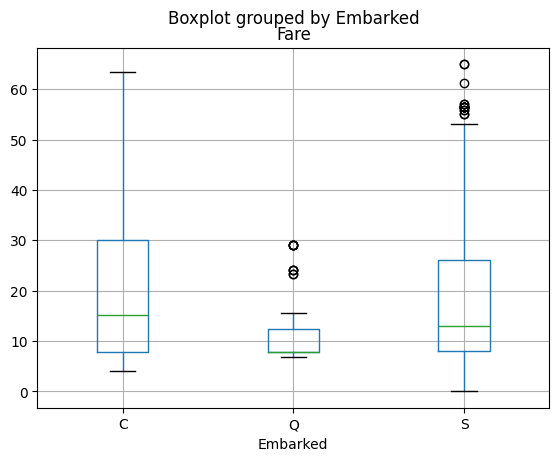

In [256]:
train_df.boxplot(column="Fare", by = "Embarked")
plt.show()

In [257]:
train_df["Embarked"] = train_df["Embarked"].fillna("C")
train_df[train_df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [258]:
train_df[train_df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0,PC 17599,NaN,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,NaN,2,19950,NaN,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1.0,0,PC 17569,NaN,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1.0,0,PC 17604,NaN,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1.0,0,PC 17572,NaN,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,NaN,2,CA. 2343,NaN,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1.0,0,17453,NaN,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1.0,1,36928,NaN,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,NaN,2,CA. 2343,NaN,NaN,S


In [259]:
train_df["Fare"] = train_df["Fare"].fillna(np.mean(train_df[train_df["Pclass"] == 3]["Fare"]))

In [260]:
train_df[train_df["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [261]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            188
SibSp           46
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [262]:
train_df[train_df["SibSp"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,NaN,1,349909,21.075000,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,NaN,1,382652,29.125000,NaN,Q
24,25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,NaN,1,349909,21.075000,NaN,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,NaN,2,19950,12.867449,C23 C25 C27,S
50,51,0,3,"Panula, Master. Juha Niilo",male,7.0,NaN,1,3101295,39.687500,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,NaN,2,CA 2144,46.900000,NaN,S
63,64,0,3,"Skoog, Master. Harald",male,4.0,NaN,2,347088,27.900000,NaN,S
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17.0,NaN,2,3101281,7.925000,NaN,S
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16.0,NaN,2,CA 2144,46.900000,NaN,S
85,86,1,3,"Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...",female,33.0,NaN,0,3101278,15.850000,NaN,S


In [263]:
train_df["SibSp"] = train_df["SibSp"].fillna(train_df["SibSp"].mean())

In [264]:
train_df[train_df["SibSp"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [265]:
train_df[train_df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0.000000,0,330877,8.458300,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0.000000,0,244373,13.000000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0.000000,0,2649,7.225000,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0.000000,0,2631,7.225000,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0.000000,0,330959,7.879200,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0.000000,0,2629,7.229200,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,0.313609,2,CA. 2343,12.867449,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0.000000,0,345777,9.500000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0.000000,0,349217,7.895800,NaN,S


In [266]:
train_df.Age.mean()

np.float64(29.07207681365576)

In [267]:
train_df.Sex = train_df.Sex.astype("category")

In [268]:
train_df.groupby(by = "Sex").Age.median()

Sex
female    27.0
male      28.0
Name: Age, dtype: float64

In [269]:
train_df["Age"] = train_df["Age"].fillna(
    train_df.groupby("Sex")["Age"].transform("mean"))

In [270]:
train_df.Age.isnull().sum()

np.int64(0)

In [271]:
train_df = pd.get_dummies(train_df, columns = ["Sex"])

In [272]:
name = train_df["Name"]
train_df["Title"] = [i.split(".")[0].split(",")[-1].strip() for i in name]
train_df.Title.head(10)

train_df["Title"] = train_df["Title"].replace(["Lady","the Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],"other")
train_df["Title"] = [0 if i == "Master" else 1 if i == "Miss" or i == "Ms" or i == "Mlle" or i == "Mrs" else 2 if i == "Mr" else 3 for i in train_df["Title"]]
train_df["Title"].head(40)

0     2
1     1
2     1
3     1
4     2
5     2
6     2
7     0
8     1
9     1
10    1
11    1
12    2
13    2
14    1
15    1
16    0
17    2
18    1
19    1
20    2
21    2
22    1
23    2
24    1
25    1
26    2
27    2
28    1
29    2
30    3
31    1
32    1
33    2
34    2
35    2
36    2
37    2
38    1
39    1
Name: Title, dtype: int64

In [273]:
train_df.drop(labels = ["Name"], axis = 1, inplace = True)

In [274]:
#train_df = pd.get_dummies(train_df, columns = ["Sex"])
train_df = pd.get_dummies(train_df, columns = ["Embarked"])

In [275]:
train_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.000000,1.0,0,A/5 21171,7.250000,NaN,False,True,2,False,False,True
1,2,1,1,38.000000,1.0,0,PC 17599,12.867449,C85,True,False,1,True,False,False
2,3,1,3,26.000000,0.0,0,STON/O2. 3101282,7.925000,NaN,True,False,1,False,False,True
3,4,1,1,35.000000,1.0,0,113803,53.100000,C123,True,False,1,False,False,True
4,5,0,3,35.000000,0.0,0,373450,8.050000,NaN,False,True,2,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0.0,0,211536,13.000000,NaN,False,True,3,False,False,True
887,888,1,1,19.000000,0.0,0,112053,30.000000,B42,True,False,1,False,False,True
888,889,0,3,27.915709,1.0,2,W./C. 6607,23.450000,NaN,True,False,1,False,False,True
889,890,1,1,26.000000,0.0,0,111369,30.000000,C148,False,True,2,True,False,False


In [276]:

train_df["Fsize"] = train_df["SibSp"] + train_df["Parch"] + 1

In [277]:
train_df["family_size"] = [1 if i < 5 else 0 for i in train_df["Fsize"]]

In [278]:
train_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Title,Embarked_C,Embarked_Q,Embarked_S,Fsize,family_size
0,1,0,3,22.0,1.0,0,A/5 21171,7.250000,NaN,False,True,2,False,False,True,2.0,1
1,2,1,1,38.0,1.0,0,PC 17599,12.867449,C85,True,False,1,True,False,False,2.0,1
2,3,1,3,26.0,0.0,0,STON/O2. 3101282,7.925000,NaN,True,False,1,False,False,True,1.0,1
3,4,1,1,35.0,1.0,0,113803,53.100000,C123,True,False,1,False,False,True,2.0,1
4,5,0,3,35.0,0.0,0,373450,8.050000,NaN,False,True,2,False,False,True,1.0,1


In [279]:
train_df = pd.get_dummies(train_df, columns = ["family_size"]);train_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_female,Sex_male,Title,Embarked_C,Embarked_Q,Embarked_S,Fsize,family_size_0,family_size_1
0,1,0,3,22.0,1.0,0,A/5 21171,7.250000,NaN,False,True,2,False,False,True,2.0,False,True
1,2,1,1,38.0,1.0,0,PC 17599,12.867449,C85,True,False,1,True,False,False,2.0,False,True
2,3,1,3,26.0,0.0,0,STON/O2. 3101282,7.925000,NaN,True,False,1,False,False,True,1.0,False,True
3,4,1,1,35.0,1.0,0,113803,53.100000,C123,True,False,1,False,False,True,2.0,False,True
4,5,0,3,35.0,0.0,0,373450,8.050000,NaN,False,True,2,False,False,True,1.0,False,True


In [280]:
train_df[["Embarked_C","Embarked_Q","Embarked_S"]].astype(int)

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,0,0,1
889,1,0,0


In [281]:
train_df.Ticket.head(20)

0            A/5 21171
1             PC 17599
2     STON/O2. 3101282
3               113803
4               373450
5               330877
6                17463
7               349909
8               347742
9               237736
10             PP 9549
11              113783
12           A/5. 2151
13              347082
14              350406
15              248706
16              382652
17              244373
18              345763
19                2649
Name: Ticket, dtype: str

In [282]:
a = "A/5. 2151"
a.replace(".","").replace("/","").strip().split(" ")[0]

'A5'

In [283]:
tickets = []

for i in list(train_df.Ticket):
    if not i.isdigit():
        tickets.append(i.replace(".","").replace("/","").strip().split(" ")[0])
    else:
        tickets.append("x")
train_df["Ticket"] = tickets

In [284]:
train_df.Ticket.head(20)

0         A5
1         PC
2     STONO2
3          x
4          x
5          x
6          x
7          x
8          x
9          x
10        PP
11         x
12        A5
13         x
14         x
15         x
16         x
17         x
18         x
19         x
Name: Ticket, dtype: str

In [285]:
train_df = pd.get_dummies(train_df, columns = ["Ticket"], prefix = "t")
train_df.head(10)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,...,t_SOPP,t_SOTONO2,t_SOTONOQ,t_SP,t_STONO,t_STONO2,t_SWPP,t_WC,t_WEP,t_x
0,1,0,3,22.00000,1.000000,0,7.250000,NaN,False,True,...,False,False,False,False,False,False,False,False,False,False
1,2,1,1,38.00000,1.000000,0,12.867449,C85,True,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,26.00000,0.000000,0,7.925000,NaN,True,False,...,False,False,False,False,False,True,False,False,False,False
3,4,1,1,35.00000,1.000000,0,53.100000,C123,True,False,...,False,False,False,False,False,False,False,False,False,True
4,5,0,3,35.00000,0.000000,0,8.050000,NaN,False,True,...,False,False,False,False,False,False,False,False,False,True
5,6,0,3,29.75491,0.000000,0,8.458300,NaN,False,True,...,False,False,False,False,False,False,False,False,False,True
6,7,0,1,54.00000,0.000000,0,51.862500,E46,False,True,...,False,False,False,False,False,False,False,False,False,True
7,8,0,3,2.00000,0.313609,1,21.075000,NaN,False,True,...,False,False,False,False,False,False,False,False,False,True
8,9,1,3,27.00000,0.000000,2,11.133300,NaN,True,False,...,False,False,False,False,False,False,False,False,False,True
9,10,1,2,14.00000,1.000000,0,30.070800,NaN,True,False,...,False,False,False,False,False,False,False,False,False,True


In [286]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 48 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Age            891 non-null    float64
 4   SibSp          891 non-null    float64
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Cabin          204 non-null    str    
 8   Sex_female     891 non-null    bool   
 9   Sex_male       891 non-null    bool   
 10  Title          891 non-null    int64  
 11  Embarked_C     891 non-null    bool   
 12  Embarked_Q     891 non-null    bool   
 13  Embarked_S     891 non-null    bool   
 14  Fsize          891 non-null    float64
 15  family_size_0  891 non-null    bool   
 16  family_size_1  891 non-null    bool   
 17  t_A4           891 non-null    bool   
 18  t_A5           891 no

In [287]:
bool_cols = train_df.select_dtypes(include="bool").columns
train_df[bool_cols] = train_df[bool_cols].astype(int)

In [288]:
train_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Sex_female,Sex_male,...,t_SOPP,t_SOTONO2,t_SOTONOQ,t_SP,t_STONO,t_STONO2,t_SWPP,t_WC,t_WEP,t_x
0,1,0,3,22.0,1.0,0,7.250000,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,38.0,1.0,0,12.867449,C85,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,3,26.0,0.0,0,7.925000,NaN,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,1,1,35.0,1.0,0,53.100000,C123,1,0,...,0,0,0,0,0,0,0,0,0,1
4,5,0,3,35.0,0.0,0,8.050000,NaN,0,1,...,0,0,0,0,0,0,0,0,0,1


In [289]:
train_df.drop(labels = ["PassengerId","Cabin"], axis = 1, inplace = True)

In [290]:
train_df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Sex_male', 'Title', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Fsize',
       'family_size_0', 'family_size_1', 't_A4', 't_A5', 't_AS', 't_C', 't_CA',
       't_CASOTON', 't_FC', 't_FCC', 't_Fa', 't_LINE', 't_PC', 't_PP', 't_PPP',
       't_SC', 't_SCA4', 't_SCAH', 't_SCOW', 't_SCPARIS', 't_SCParis', 't_SOC',
       't_SOP', 't_SOPP', 't_SOTONO2', 't_SOTONOQ', 't_SP', 't_STONO',
       't_STONO2', 't_SWPP', 't_WC', 't_WEP', 't_x'],
      dtype='str')

In [291]:
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [292]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [293]:
X_train = train_df.drop(labels = "Survived", axis = 1)
y_train = train_df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size = 0.33, random_state=42)

print("X_train", len(X_train))
print("X_test", len(X_test))
print("y_train", len(y_train))
print("y_test", len(y_test))


X_train 596
X_test 295
y_train 596
y_test 295


In [294]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

acc_log_train = round(logreg.score(X_train, y_train)*100,2)
acc_log_test = round(logreg.score(X_test, y_test)*100,2)

print("Training Accuracy:",acc_log_train)
print("Testing Accuracy:",acc_log_test)

Training Accuracy: 80.03
Testing Accuracy: 82.03


C:\Users\mertc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning:

lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [295]:
param_grid = {"max_features":[1,3,10],
              "min_samples_split":[2,3,10],
              "min_samples_leaf": [1,3,10],
              "bootstrap": [False],
              "n_estimators":[100,300],
              "criterion":["gini"]}

model = RandomForestClassifier(random_state= 42)

grid_search = GridSearchCV(
    estimator= model,
    param_grid = param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'bootstrap': False, 'criterion': 'gini', 'max_features': 3, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 300}
Best Score: 0.8221848739495797


In [296]:
final_model_rf = RandomForestClassifier(bootstrap=False,
                                        criterion="gini",
                                        max_features=3,
                                        min_samples_leaf=3,
                                        min_samples_split=10,
                                        n_estimators=300,
                                        random_state=42)

final_model_rf.fit(X_train, y_train)

y_pred = final_model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", accuracy_rf)

Final Test Accuracy: 0.823728813559322


In [297]:
dt_param_grid = {"min_samples_split":range(10,500,20),
                 "max_depth": range(1,20,2)}

model = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator= model,
    param_grid = dt_param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 9, 'min_samples_split': 170}
Best Score: 0.810378151260504


In [298]:
final_model_dt = DecisionTreeClassifier(max_depth=9,
                                       min_samples_split=170,
                                       random_state=42)

final_model_dt.fit(X_train, y_train)

y_pred = final_model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", accuracy_dt)

Final Test Accuracy: 0.7762711864406779


In [299]:
svc_param_grid = {
    "kernel" : ["rbf"],
    "gamma":[0.001,0.01,0.1,1],
    "C":[1,10,50,100,200,300,1000]}

model = SVC(random_state=42)

grid_search = GridSearchCV(
    estimator= model,
    param_grid = svc_param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best Score: 0.7953921568627451


In [300]:
final_model_svc = SVC(kernel="rbf",
                      C=100,
                      gamma=0.001,random_state=42)

final_model_svc.fit(X_train, y_train)

y_pred = final_model_svc.predict(X_test)

accuracy_svc = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", accuracy_svc)                
                      

Final Test Accuracy: 0.8305084745762712


In [301]:
knn_param_grid = {"n_neighbors": np.linspace(1,19,10, dtype = int).tolist(),
                  "weights": ["uniform","distance"],
                  "metric":["euclidean","manhattan"]}

model = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator= model,
    param_grid = knn_param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best Score: 0.7718627450980392


In [302]:
final_model_knn = KNeighborsClassifier(metric="manhattan",
                                       n_neighbors=5, 
                                       weights="uniform")
final_model_knn.fit(X_train, y_train)

y_pred = final_model_knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", accuracy_knn)                                                 

Final Test Accuracy: 0.7932203389830509


In [303]:
models = ["SVC", "Decision Tree", "Random Forest","KNeighbors Classifier"]
scores = [accuracy_svc, accuracy_dt, accuracy_rf,accuracy_knn]

results = pd.DataFrame({
    "ML Models": models,
    "CV Accuracy Mean": scores
})

In [304]:
results.sort_values(by= "CV Accuracy Mean",ascending = False)

,ML Models,CV Accuracy Mean
0,SVC,0.830508
2,Random Forest,0.823729
3,KNeighbors Classifier,0.793220
1,Decision Tree,0.776271


<Axes: xlabel='ML Models', ylabel='CV Accuracy Mean'>

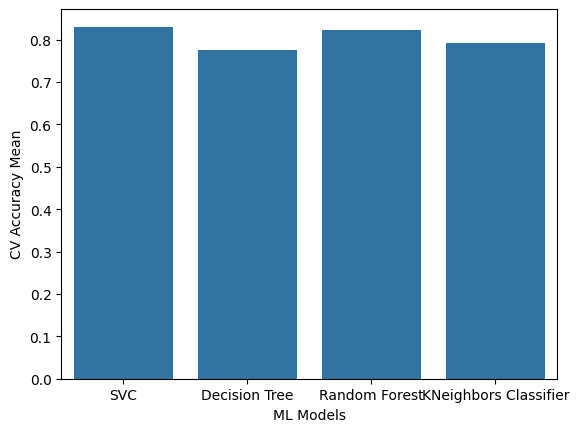

In [305]:
sns.barplot(results, x = "ML Models", y = "CV Accuracy Mean")